This is a project to demonstraght fetching GIS sask data and naking maps. I want to make a map of Sask which I will then simulate sampling sites and contamination zones. 

In [8]:
# import librays
import geopandas as gpd
import matplotlib.pyplot as plt


In [ ]:
# Pull Canadian provinces directly from the web as a GeoJSON  
url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/canada.geojson"
gdf = gpd.read_file(url)
print(gdf[["name"]].to_string())  # see all province/territory names
sk = gdf[gdf["name"] == "Saskatchewan"].copy() # isolate just Saskatchewan

                         name
0                      Quebec
1   Newfoundland and Labrador
2            British Columbia
3                     Nunavut
4       Northwest Territories
5               New Brunswick
6                 Nova Scotia
7                Saskatchewan
8                     Alberta
9        Prince Edward Island
10            Yukon Territory
11                   Manitoba
12                    Ontario


(1, 5)
EPSG:4326
MultiPolygon


<Axes: >

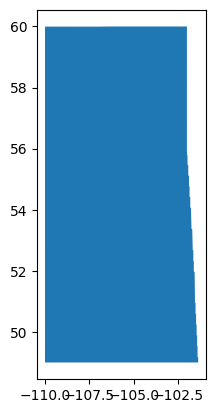

In [ ]:
print(sk.shape)     
print(sk.crs)          # check the coordinate system
print(sk.geometry.geom_type.values[0])  # should say "Polygon" or "MultiPolygon"
sk.plot()              # quick visual sanity check

I have pulled the GIS data and got a rough map of sask. Now I will move onto CRS - Coordinate Reference System 

In [ ]:
# The raw data is in WGS84 (lat/lon degrees) — EPSG:4326
# For any area or distance calculations we need a projected CRS
# EPSG:3347 is Statistics Canada Lambert — the standard for Canadian data

print("Current CRS:", sk.crs)
print("Is geographic (lat/lon)?", sk.crs.is_geographic)

# Reproject to Canada Lambert
sk_projected = sk.to_crs(epsg=3347) # Put into Canada Lambert

print("\nNew CRS:", sk_projected.crs)
print("Is geographic?", sk_projected.crs.is_geographic)

# Now we can calculate area in real units
area_km2 = sk_projected.geometry.area.values[0] / 1_000_000
print(f"\nSaskatchewan area: {area_km2:,.0f} km²")
print("(Real value: ~651,900 km² — how close are we?)")

Current CRS: EPSG:4326
Is geographic (lat/lon)? True

New CRS: EPSG:3347
Is geographic? False

Saskatchewan area: 631,834 km²
(Real value: ~651,900 km² — how close are we?)


I have converted the CRS from GPS to the Canadian Lambert system. This is the best CRS for Canada. There is a 20K km^2 difference between my map and the real dimensions of Sask. 

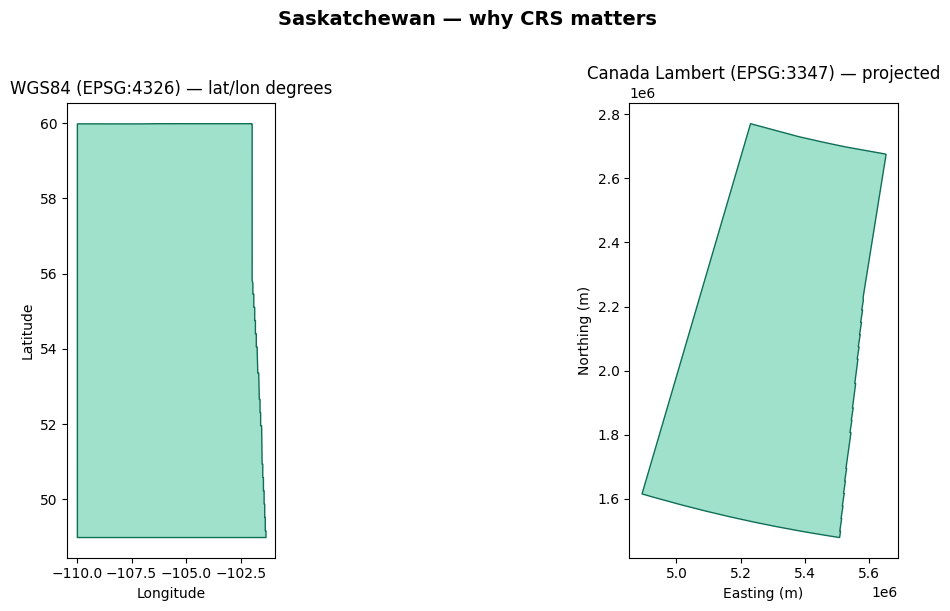

Saved: day1_crs_comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: geographic CRS (WGS84) - looks stretched
sk.plot(ax=axes[0], color="#9FE1CB", edgecolor="#0F6E56", linewidth=1)
axes[0].set_title("WGS84 (EPSG:4326) — lat/lon degrees", fontsize=12)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# Right: projected CRS — correct proportions
sk_projected.plot(ax=axes[1], color="#9FE1CB", edgecolor="#0F6E56", linewidth=1)
axes[1].set_title("Canada Lambert (EPSG:3347) — projected", fontsize=12)
axes[1].set_xlabel("Easting (m)")
axes[1].set_ylabel("Northing (m)")

plt.suptitle("Saskatchewan — why CRS matters", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("day1_crs_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: day1_crs_comparison.png")

Here we see why using the correct CRS is important. The right plot is more accurate and better for mappping and decision making. 

In [10]:
import pandas as pd
from shapely.geometry import Point

# Simulate 8 field sampling sites across Saskatchewan
sites_data = {
    "site_id":   ["SK-001", "SK-002", "SK-003", "SK-004", "SK-005", "SK-006", "SK-007", "SK-008"],
    "name":      ["Waskesiu", "Weyburn", "Prince Albert", "Swift Current", "Yorkton", "La Ronge", "Meadow Lake", "Estevan"],
    "parameter": ["pH", "pH", "conductivity", "conductivity", "pH", "conductivity", "pH", "conductivity"],
    "value":     [7.2, 6.8, 450, 380, 7.5, 290, 6.9, 510],
    "longitude": [-106.07, -103.85, -105.68, -107.80, -102.46, -105.29, -108.44, -102.98],
    "latitude":  [53.92,   49.66,   53.20,    50.29,   51.21,   55.10,   54.13,   49.14]
}

sites_df = pd.DataFrame(sites_data)

# Convert to GeoDataFrame — this is the key move
sites_gdf = gpd.GeoDataFrame(
    sites_df,
    geometry=gpd.points_from_xy(sites_df["longitude"], sites_df["latitude"]),
    crs="EPSG:4326"   # always set CRS when creating from lat/lon
)

print(type(sites_gdf))  # confirm it's a GeoDataFrame, not a plain DataFrame
print("\nSample sites:")
print(sites_gdf[["site_id", "name", "parameter", "value", "geometry"]])

<class 'geopandas.geodataframe.GeoDataFrame'>

Sample sites:
  site_id           name     parameter  value               geometry
0  SK-001       Waskesiu            pH    7.2  POINT (-106.07 53.92)
1  SK-002        Weyburn            pH    6.8  POINT (-103.85 49.66)
2  SK-003  Prince Albert  conductivity  450.0   POINT (-105.68 53.2)
3  SK-004  Swift Current  conductivity  380.0   POINT (-107.8 50.29)
4  SK-005        Yorkton            pH    7.5  POINT (-102.46 51.21)
5  SK-006       La Ronge  conductivity  290.0   POINT (-105.29 55.1)
6  SK-007    Meadow Lake            pH    6.9  POINT (-108.44 54.13)
7  SK-008        Estevan  conductivity  510.0  POINT (-102.98 49.14)


/var/folders/hv/tj8zjgyd3qncstnpt_ttykgr0000gn/T/ipykernel_19723/3866426110.py:24: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title="Parameter", loc="lower right")


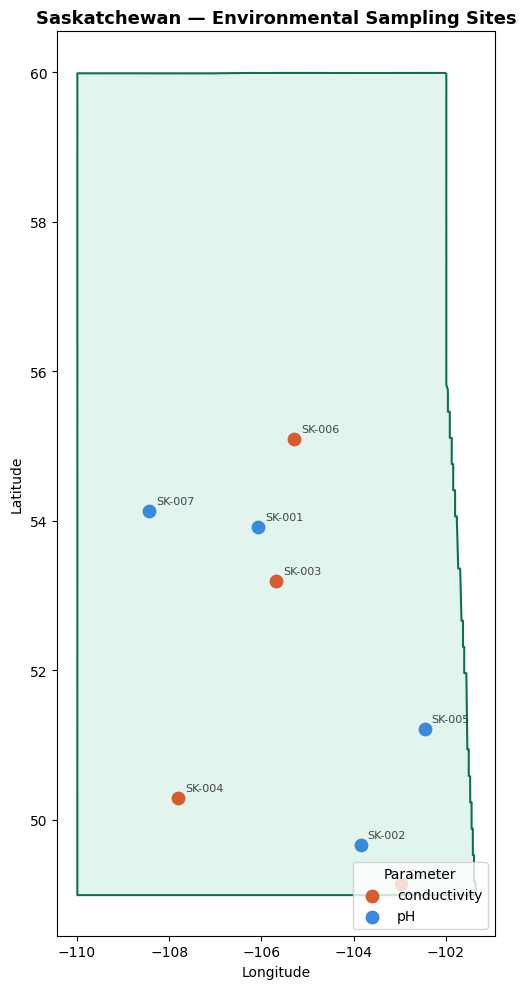

Saved: day1_sampling_sites.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 10))

# Base layer: Saskatchewan boundary
sk.plot(ax=ax, color="#E1F5EE", edgecolor="#0F6E56", linewidth=1.5, label="Saskatchewan")

# Sample sites — colour by parameter type
colors = {"pH": "#378ADD", "conductivity": "#D85A30"}
for param, group in sites_gdf.groupby("parameter"):
    group.plot(ax=ax, color=colors[param], markersize=80,
               marker="o", label=param, zorder=5)

# Add site labels
for _, row in sites_gdf.iterrows():
    ax.annotate(
        row["site_id"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5), textcoords="offset points",
        fontsize=8, color="#444441"
    )

ax.set_title("Saskatchewan — Environmental Sampling Sites", fontsize=13, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title="Parameter", loc="lower right")
plt.tight_layout()
plt.savefig("day1_sampling_sites.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: day1_sampling_sites.png")

I have now created my sites which are just Sask towns as this is a simulation and towns are verifiable.

In [ ]:


# 1. Check and set CRS
print("CRS:", sites_gdf.crs)
sites_proj = sites_gdf.to_crs(epsg=3347)

# 2. Get bounding box
print("Bounds:", sites_gdf.total_bounds)  # [minx, miny, maxx, maxy]

# 3. Get geometry type
print("Geom types:", sites_gdf.geometry.geom_type.unique())

# 4. Access coordinates from a point
first_point = sites_gdf.geometry.iloc[0]
print(f"First site coords: ({first_point.x:.4f}, {first_point.y:.4f})")

# 5. Check which sites are within Saskatchewan boundary
sk_union = sk.geometry.union_all()  # merge all polygons into one
sites_gdf["in_sk"] = sites_gdf.geometry.within(sk_union)
print("\nSites within SK boundary:")
print(sites_gdf[["site_id", "in_sk"]])

import os
os.makedirs("data", exist_ok=True)
print("Folder ready:", os.path.abspath("data"))

# 6. Export to GeoPackage (the modern alternative to shapefile)
sites_gdf.to_file("data/sampling_sites.gpkg", driver="GPKG")
print("\nSaved to GeoPackage: data/sampling_sites.gpkg")

CRS: EPSG:4326
Bounds: [-108.44   49.14 -102.46   55.1 ]
Geom types: ['Point']
First site coords: (-106.0700, 53.9200)

Sites within SK boundary:
  site_id  in_sk
0  SK-001   True
1  SK-002   True
2  SK-003   True
3  SK-004   True
4  SK-005   True
5  SK-006   True
6  SK-007   True
7  SK-008   True
Folder ready: /Users/dawsonconlon/Coding/Python/GIS/data

Saved to GeoPackage: data/sampling_sites.gpkg


I have saved this data and I can now export this for future use.